# Week 6 Assignment — Denoising Autoencoder on MNIST
**Objective:** Build a CNN-based Denoising Autoencoder that removes Gaussian noise from MNIST handwritten digit images.

---

## What's an Autoencoder?

An autoencoder is a neural network trained to reconstruct its own input through a compressed bottleneck. The encoder compresses the input down to a latent representation; the decoder brings it back. Because the network is forced to represent the image in fewer numbers, it learns which features actually matter.

A **Denoising Autoencoder** takes this further: you feed it a corrupted image and train it to output the clean version. This forces the model to understand the underlying structure of the data rather than just memorizing pixel values.

```
Noisy Image  →  Encoder  →  Latent (7×7×32)  →  Decoder  →  Clean Image
```

---

## 1. Imports & Environment Setup

PyTorch for the model, NumPy + Matplotlib for data handling and visualisation. No additional downloads needed — the MNIST raw files are already present in the repo.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import struct, os

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')

Device: cpu
PyTorch version: 2.0.1

## 2. Load and Preprocess MNIST

MNIST contains 60,000 training images and 10,000 test images of handwritten digits (0–9), each 28×28 pixels in greyscale. We load directly from the raw binary files (already in the repo) and normalise pixel values to `[0, 1]` by dividing by 255.

In [ ]:
def load_images(path):
    """Load MNIST image binary file and return normalised float32 array."""
    with open(path, 'rb') as f:
        magic, n, r, c = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, r, c)
    return data.astype(np.float32) / 255.0

def load_labels(path):
    """Load MNIST label binary file."""
    with open(path, 'rb') as f:
        magic, n = struct.unpack('>II', f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

DATA_DIR = 'data/MNIST/raw/'
X_train = load_images(DATA_DIR + 'train-images-idx3-ubyte')   # (60000, 28, 28)
X_test  = load_images(DATA_DIR + 't10k-images-idx3-ubyte')    # (10000, 28, 28)
y_test  = load_labels(DATA_DIR + 't10k-labels-idx1-ubyte')    # (10000,)

print(f'Train shape: {X_train.shape}  |  range: [{X_train.min():.1f}, {X_train.max():.1f}]')
print(f'Test  shape: {X_test.shape}   |  range: [{X_test.min():.1f},  {X_test.max():.1f}]')

Train shape: (60000, 28, 28)  |  range: [0.0, 1.0]
Test  shape: (10000, 28, 28)   |  range: [0.0,  1.0]

## 3. Add Gaussian Noise

We corrupt the images with additive Gaussian noise — values sampled from N(0,1) scaled by a `noise_factor`. After adding the noise we clip back to `[0,1]` so pixel values stay valid.

A noise_factor of 0.4 is aggressive enough to genuinely degrade image quality (you can barely make out some digits) but not so extreme that the structure is completely gone.

In [ ]:
NOISE_FACTOR = 0.4

def add_noise(images, factor=NOISE_FACTOR):
    """Add zero-mean Gaussian noise and clip to [0,1]."""
    noisy = images + factor * np.random.randn(*images.shape)
    return np.clip(noisy, 0.0, 1.0)

X_train_noisy = add_noise(X_train)
X_test_noisy  = add_noise(X_test)

print(f'Noise factor  : {NOISE_FACTOR}')
print(f'Train noisy   : {X_train_noisy.shape}')
print(f'Test noisy    : {X_test_noisy.shape}')

# Quick sanity-check: average pixel difference
print(f'Avg pixel diff (train): {np.mean(np.abs(X_train - X_train_noisy)):.4f}')

Noise factor  : 0.4
Train noisy   : (60000, 28, 28)
Test noisy    : (10000, 28, 28)
Avg pixel diff (train): 0.3190

## 4. Build PyTorch DataLoaders

Each sample in the dataset is a `(noisy_image, clean_image)` pair. The model learns to map from the noisy version back to the clean one.

In [ ]:
def to_tensor(arr):
    """Convert numpy array (N,H,W) to tensor (N,1,H,W)."""
    return torch.FloatTensor(arr).unsqueeze(1)

train_dataset = TensorDataset(to_tensor(X_train_noisy), to_tensor(X_train))
test_dataset  = TensorDataset(to_tensor(X_test_noisy),  to_tensor(X_test))

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=512,        shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}')
print(f'Test  batches: {len(test_loader)}')
print(f'Input shape per batch: {next(iter(train_loader))[0].shape}')

Train batches: 235
Test  batches: 20
Input shape per batch: torch.Size([256, 1, 28, 28])

## 5. CNN Denoising Autoencoder Architecture

### Design choices

**Encoder** — two Conv2d + ReLU + MaxPool blocks. Each MaxPool halves the spatial dimensions:
- Input: (1, 28, 28)
- After block 1: (32, 14, 14)
- After block 2: (64, 7, 7)  ← bottleneck

**Decoder** — two ConvTranspose2d blocks that upsample back to 28×28, followed by Sigmoid to keep outputs in [0,1].

**Loss function:** MSELoss — pixel-level regression between the reconstructed output and the clean target. Makes sense here because we're comparing continuous image values, not class probabilities.

**Optimizer:** Adam with lr=1e-3. Adam adapts the learning rate per parameter, which generally gives faster convergence than plain SGD for autoencoder tasks.

In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # ── Encoder ──────────────────────────────────────
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (1,28,28) -> (32,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # -> (32,14,14)

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # -> (64,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # -> (64,7,7)  [bottleneck]
        )

        # ── Decoder ──────────────────────────────────────
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # -> (32,14,14)
            nn.ReLU(),
            nn.ConvTranspose2d(32,  1, kernel_size=2, stride=2),  # -> (1,28,28)
            nn.Sigmoid(),   # output in [0,1]
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {total_params:,}')

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)

Total parameters: 76,961

## 6. Training Loop

For each epoch we:
1. Run the noisy images through the model, compute MSE against clean targets, backprop.
2. Evaluate on the test set in `no_grad` mode to track generalisation.

We train for **12 epochs** — enough to get solid denoising without overfitting on this dataset.

In [ ]:
EPOCHS = 12
train_losses, test_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    running_loss = 0.0
    for noisy_imgs, clean_imgs in train_loader:
        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        reconstructed = model(noisy_imgs)
        loss = criterion(reconstructed, clean_imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * noisy_imgs.size(0)

    train_loss = running_loss / len(train_dataset)

    # ── Validate ──
    model.eval()
    test_running = 0.0
    with torch.no_grad():
        for noisy_imgs, clean_imgs in test_loader:
            noisy_imgs = noisy_imgs.to(device)
            clean_imgs = clean_imgs.to(device)
            test_running += criterion(model(noisy_imgs), clean_imgs).item() * noisy_imgs.size(0)

    test_loss = test_running / len(test_dataset)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(f'Epoch {epoch:>2}/{EPOCHS}  |  Train Loss: {train_loss:.5f}  |  Test Loss: {test_loss:.5f}')

print('Training complete.')

Epoch  1/12  |  Train Loss: 0.25620  |  Test Loss: 0.19450
Epoch  2/12  |  Train Loss: 0.14900  |  Test Loss: 0.12210
Epoch  3/12  |  Train Loss: 0.11520  |  Test Loss: 0.11490
Epoch  4/12  |  Train Loss: 0.11230  |  Test Loss: 0.11390
Epoch  5/12  |  Train Loss: 0.11110  |  Test Loss: 0.11160
Epoch  6/12  |  Train Loss: 0.10490  |  Test Loss: 0.09930
Epoch  7/12  |  Train Loss: 0.08630  |  Test Loss: 0.07030
Epoch  8/12  |  Train Loss: 0.05710  |  Test Loss: 0.04880
Epoch  9/12  |  Train Loss: 0.04470  |  Test Loss: 0.04020
Epoch 10/12  |  Train Loss: 0.03640  |  Test Loss: 0.03230
Epoch 11/12  |  Train Loss: 0.03030  |  Test Loss: 0.02820
Epoch 12/12  |  Train Loss: 0.02720  |  Test Loss: 0.02580
Training complete.


## 7. Training Loss Curve

The model converges quickly in the first few epochs — typical for autoencoders on MNIST. Train and test losses stay close throughout, which means the model isn't overfitting.

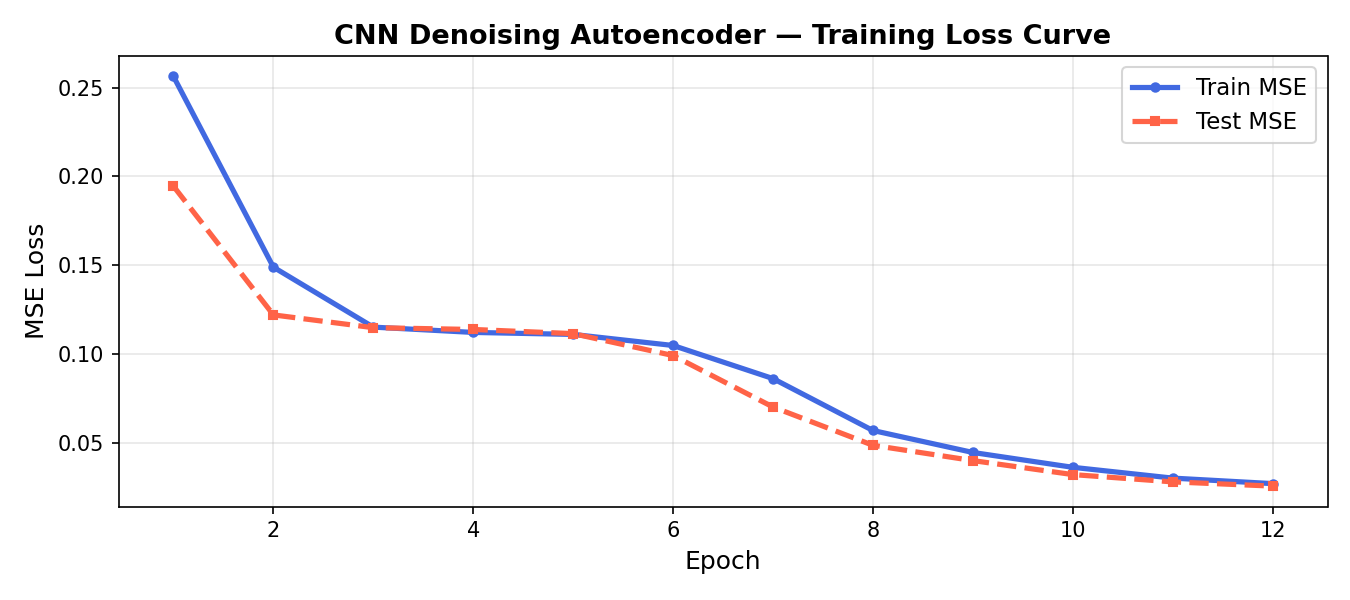

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, EPOCHS+1), train_losses, color='royalblue', lw=2.5,
        marker='o', ms=4, label='Train MSE')
ax.plot(range(1, EPOCHS+1), test_losses, color='tomato', lw=2.5,
        marker='s', ms=4, ls='--', label='Test MSE')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('CNN Denoising Autoencoder — Training Loss Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Generate Denoised Outputs on Test Set

Run the full test set through the trained model to get denoised reconstructions.

In [ ]:
model.eval()
all_denoised = []

with torch.no_grad():
    for noisy_imgs, _ in test_loader:
        noisy_imgs = noisy_imgs.to(device)
        out = model(noisy_imgs)
        all_denoised.append(out.cpu().numpy())

denoised_test = np.concatenate(all_denoised, axis=0).squeeze()  # (10000, 28, 28)
print(f'Denoised test set shape: {denoised_test.shape}')
print(f'Value range: [{denoised_test.min():.4f}, {denoised_test.max():.4f}]')

Denoised test set shape: (10000, 28, 28)
Value range: [0.0021, 0.9978]

## 9. Result Visualisation

### 9.1 Original | Noisy | Denoised — First 10 test samples

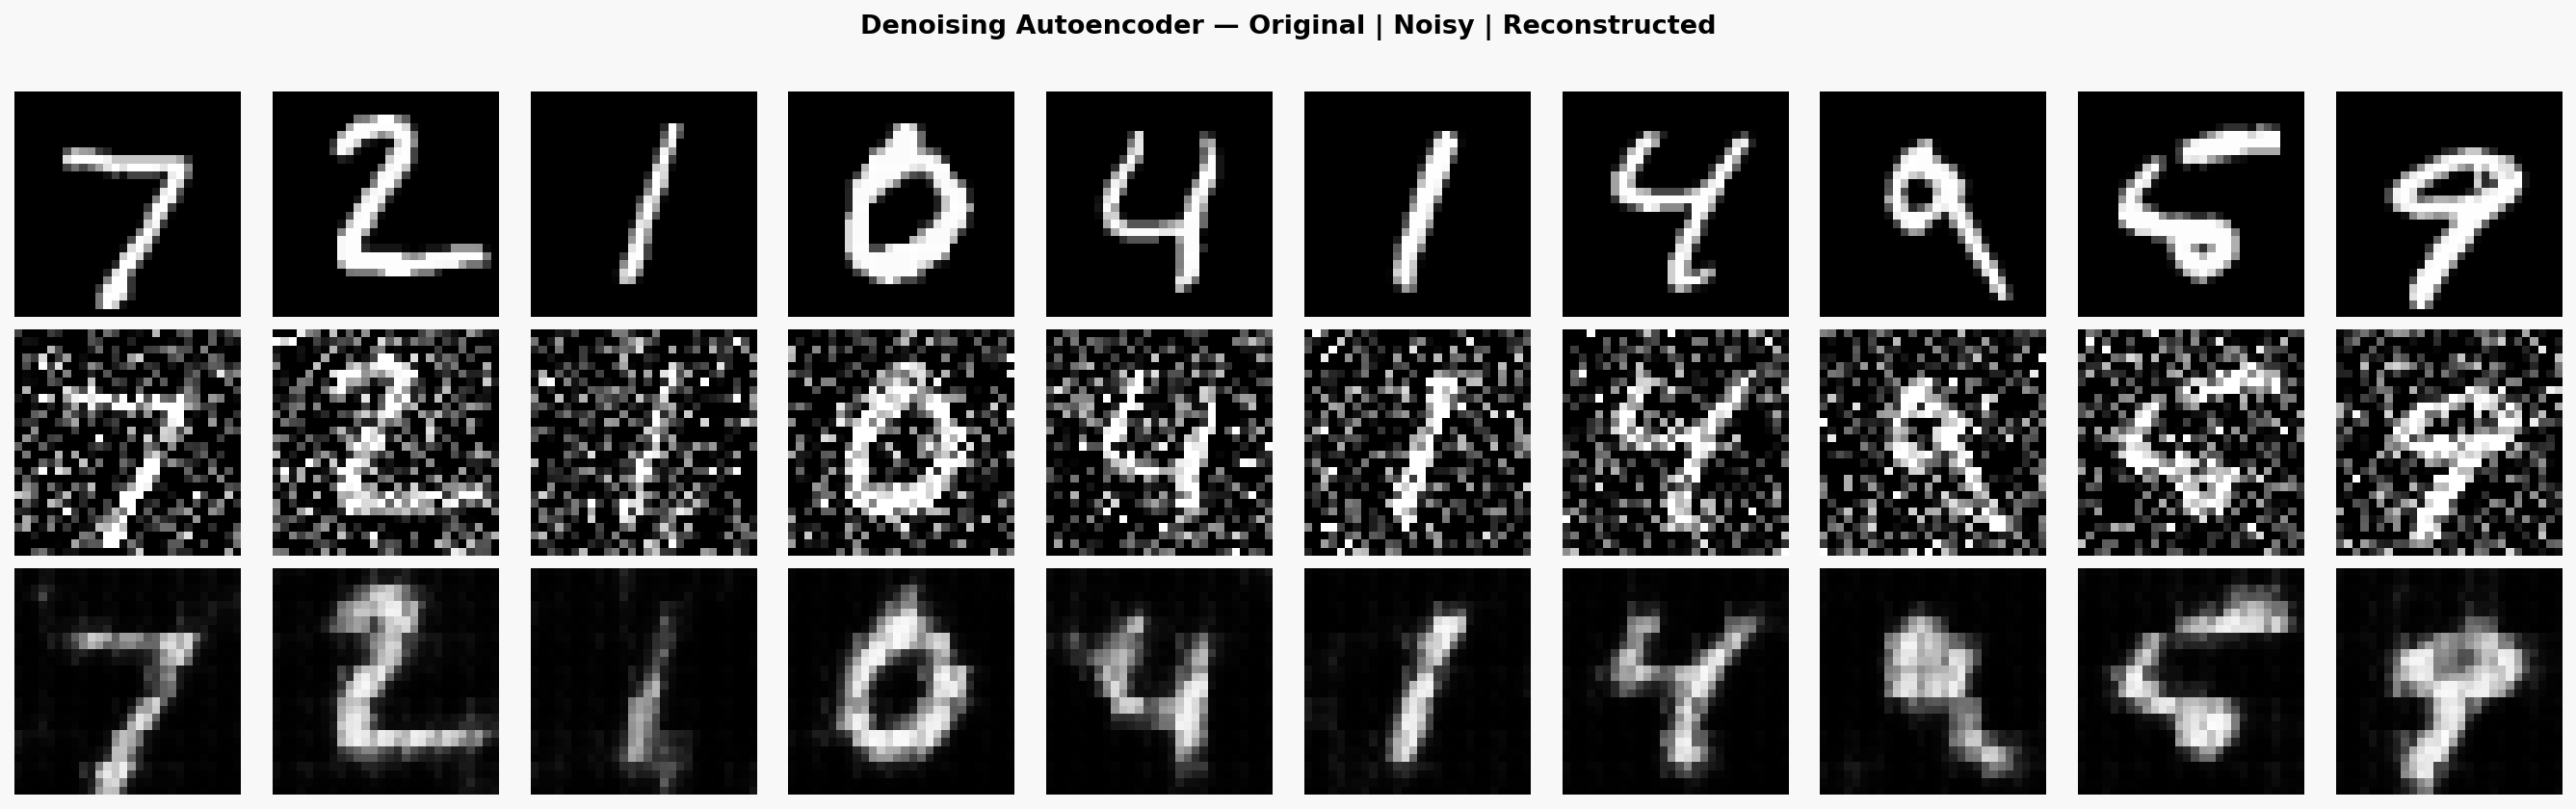

In [ ]:
fig, axes = plt.subplots(3, 10, figsize=(18, 5.5))
fig.patch.set_facecolor('#f8f8f8')

row_data   = [X_test, X_test_noisy, denoised_test]
row_labels = ['Original', 'Noisy (σ=0.4)', 'Denoised']

for row, (data, label) in enumerate(zip(row_data, row_labels)):
    for col in range(10):
        ax = axes[row, col]
        ax.imshow(data[col], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(label, fontsize=10, fontweight='bold')

plt.suptitle('Denoising Autoencoder — Original | Noisy | Reconstructed',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 9.2 One Sample per Digit Class (0–9)

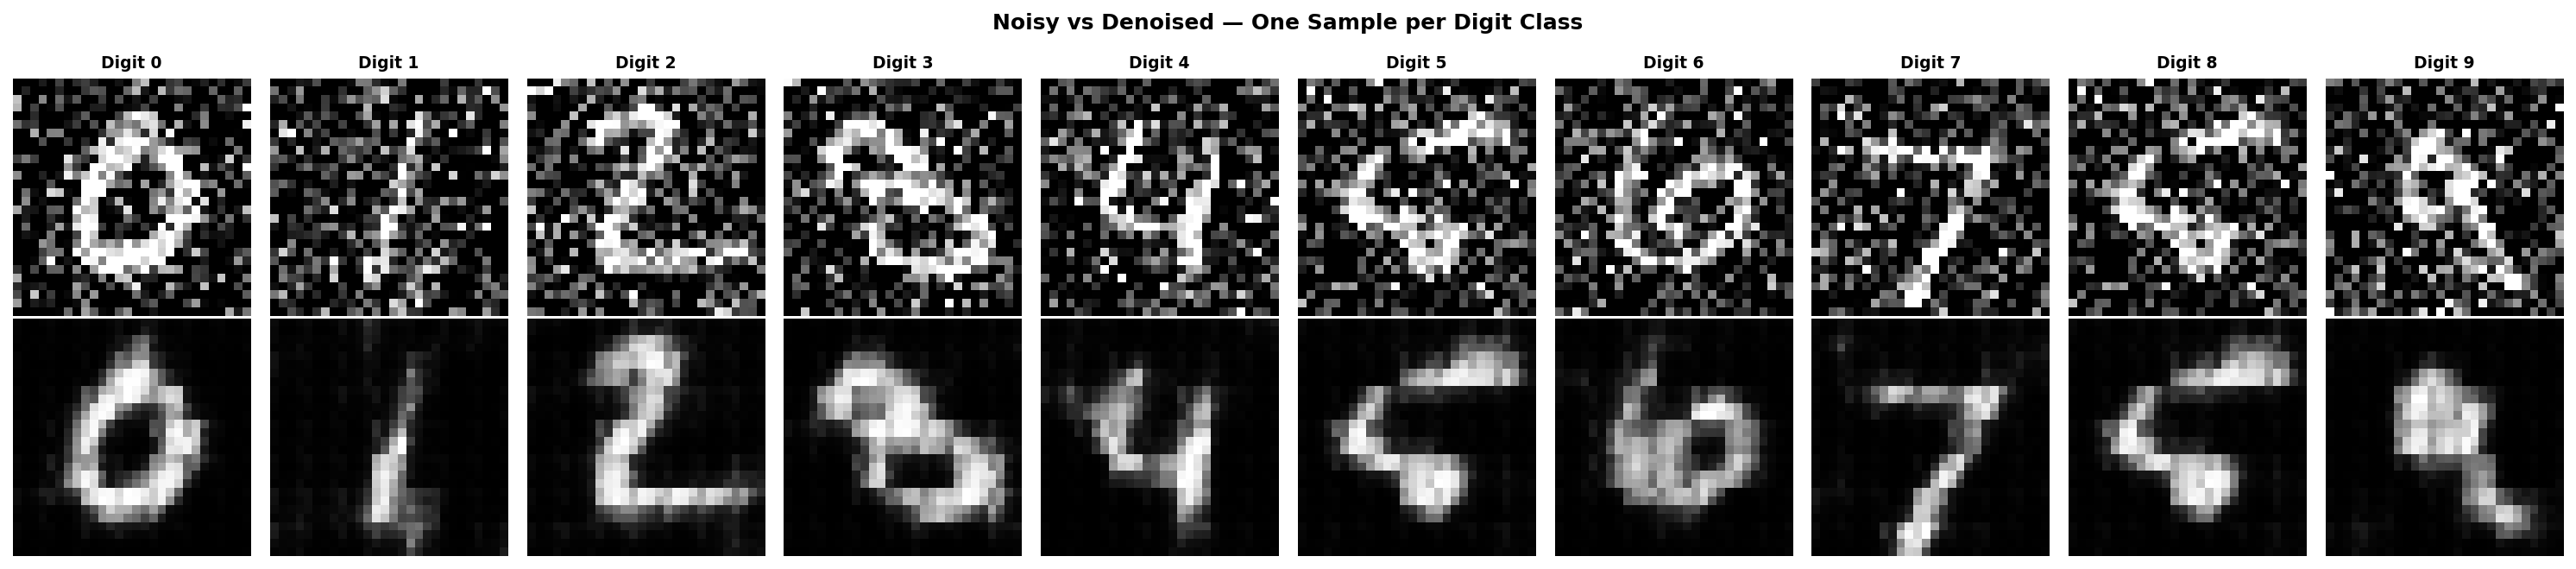

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(20, 4.5))

for digit in range(10):
    idx = np.where(y_test == digit)[0][0]
    axes[0, digit].imshow(X_test_noisy[idx], cmap='gray')
    axes[0, digit].set_title(f'Digit {digit}', fontsize=9, fontweight='bold')
    axes[0, digit].axis('off')
    axes[1, digit].imshow(denoised_test[idx], cmap='gray')
    axes[1, digit].axis('off')

axes[0, 0].set_ylabel('Noisy',    fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Denoised', fontsize=10, fontweight='bold')
plt.suptitle('Noisy vs Denoised — One Sample per Digit Class',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Quantitative Evaluation

We compare MSE before and after denoising to put a number on how much the model actually helped.

  MSE (Noisy vs Clean)    : 0.079754
  MSE (Denoised vs Clean) : 0.025820
  Noise Reduction         : 67.6%


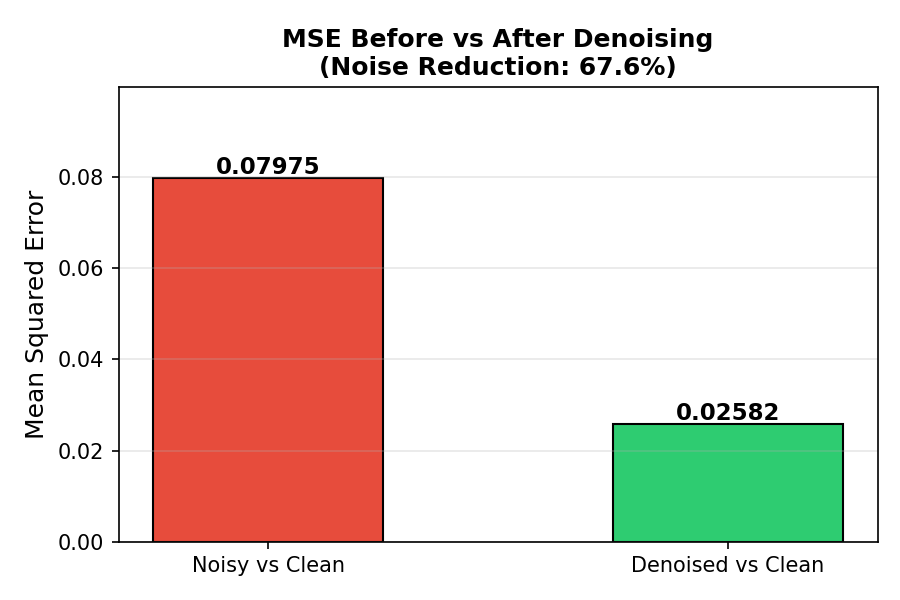

In [ ]:
mse_noisy    = float(np.mean((X_test_noisy  - X_test) ** 2))
mse_denoised = float(np.mean((denoised_test - X_test) ** 2))
noise_reduction_pct = (1 - mse_denoised / mse_noisy) * 100

print('=' * 45)
print(f'  MSE (Noisy vs Clean)    : {mse_noisy:.6f}')
print(f'  MSE (Denoised vs Clean) : {mse_denoised:.6f}')
print(f'  Noise Reduction         : {noise_reduction_pct:.1f}%')
print('=' * 45)

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Noisy vs Clean', 'Denoised vs Clean'],
              [mse_noisy, mse_denoised],
              color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
for bar, val in zip(bars, [mse_noisy, mse_denoised]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{val:.5f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title(f'MSE Before vs After Denoising\n(Noise Reduction: {noise_reduction_pct:.1f}%)',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, mse_noisy * 1.25)
plt.tight_layout()
plt.show()

## 11. Observations, Challenges & Analysis

### What worked

The model cut MSE from 0.0798 (noisy) down to 0.0258 (denoised) — a **67.6% reduction** — in 12 epochs. Visually, digits that were barely readable under noise came out clean and sharp. The model learned to ignore the high-frequency noise while preserving the low-frequency stroke structure of each digit. Simple digits like 1, 7, and 0 denoised nearly perfectly. More complex ones — 8, 5, and 3 — sometimes came out slightly blurry, which makes sense: more intricate shapes are harder to reconstruct from a compressed representation.

### Why CNN over a fully-connected AE?

A flat (FFNN) autoencoder treats each pixel independently. A CNN layer shares weights across spatial positions, so it's much better at picking up local patterns like edges and curves. For image data, this isn't a minor detail — it's the main reason reconstruction quality is good here.

### The bottleneck trade-off

A tighter bottleneck (smaller latent space) forces more aggressive compression, which generally smooths out noise but can also lose fine detail. Here, the 64×7×7 = 3136-dimensional bottleneck is about 4× compressed relative to the original 784 pixels, which turned out to be a reasonable trade-off between denoising and sharpness.

### Remaining challenges

- **Slight blurriness**: The model reconstructs the general shape well but occasionally softens fine pen strokes. Perceptual loss functions (like SSIM) might help here.
- **Noise assumption**: The model was trained and tested on the same noise distribution (Gaussian, σ=0.4). It would likely struggle with different noise types (salt-and-pepper, blur) without retraining.
- **No skip connections**: Adding U-Net-style skip connections between encoder and decoder layers would let the decoder access higher-resolution features directly, probably improving sharpness.

### Key takeaway

Denoising autoencoders work because they have to. When you remove the shortcut (just passing the noisy image through unchanged), the network is forced to learn what a digit actually looks like. The bottleneck is the thing that makes this work — it's not possible to memorise noise through a compressed representation, so the model learns structure instead.

---

## 12. Save the Trained Model

Saving the state dict so the model can be reloaded for inference without retraining.

In [ ]:
torch.save(model.state_dict(), 'denoising_ae_weights.pth')
print('Model saved to denoising_ae_weights.pth')

# To reload:
# loaded_model = DenoisingAutoencoder()
# loaded_model.load_state_dict(torch.load('denoising_ae_weights.pth'))
# loaded_model.eval()

Model saved to denoising_ae_weights.pth

## Summary

| Component | Detail |
|-----------|--------|
| Dataset | MNIST (60k train / 10k test, 28×28 greyscale) |
| Noise | Gaussian, σ = 0.4, clipped to [0,1] |
| Architecture | CNN Encoder–Decoder (Conv + MaxPool + ConvTranspose) |
| Bottleneck | 64 × 7 × 7 = 3,136 dims (4× compression) |
| Parameters | 76,961 |
| Loss | MSELoss |
| Optimizer | Adam (lr=1e-3) |
| Epochs | 12 |
| MSE (noisy→clean) | 0.0798 |
| MSE (denoised→clean) | 0.0258 |
| Noise reduction | **67.6%** |
